<a href="https://colab.research.google.com/github/Rahul9994/ML_Flyrank/blob/main/work/notebooks/w07_action_playbook.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ML-10 — Content Action Playbook

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

In [2]:
import os
REPO_URL = "https://github.com/Rahul9994/ML_Flyrank"
REPO_DIR = "ML_Flyrank"
if not os.path.isdir(REPO_DIR):
    !git clone --depth 1 {REPO_URL} {REPO_DIR}
os.chdir(REPO_DIR)

!pip install duckdb --quiet
import duckdb
from google.colab import userdata
con = duckdb.connect()
con.execute(f"CREATE SECRET (TYPE huggingface, TOKEN '{userdata.get('HF_TOKEN')}')")
base = "hf://datasets/FlyRank/internship-warehouse"

Cloning into 'ML_Flyrank'...
remote: Enumerating objects: 90, done.
remote: Counting objects: 100% (90/90), done.
remote: Compressing objects: 100% (70/70), done.
remote: Total 90 (delta 10), reused 68 (delta 4), pack-reused 0 (from 0)
Receiving objects: 100% (90/90), 1.86 MiB | 17.62 MiB/s, done.
Resolving deltas: 100% (10/10), done.


## 1. Ranked actions + reason codes

*The queue: what to do first, and why, in words a human trusts.*

Ranked actions: pages already visible (page 1 or striking distance) and under-earning
clicks for their position get flagged first for snippet/metadata review or content
refresh — the same logic from my Week-4 baseline, now with a striking-distance
(positions 11-20) category added, matching the paper's own "highest ROI optimization
zone" definition.

In [3]:
queue = con.sql(f"""
    SELECT
        client_hash_id, content_hash_id,
        AVG(avg_position_90d) AS avg_position_90d,
        MAX(content_total_impressions_90d) AS content_total_impressions_90d,
        SUM(clicks_90d) * 1.0 / NULLIF(SUM(impressions_90d),0) AS ctr,
        (1.0 / GREATEST(AVG(avg_position_90d), 1.0)) * LOG(1 + MAX(content_total_impressions_90d))
            - (SUM(clicks_90d) * 1.0 / NULLIF(SUM(impressions_90d),0)) AS score,
        CASE
            WHEN AVG(avg_position_90d) <= 10 AND MAX(content_total_impressions_90d) > 500
                THEN 'ctr_below_position_and_volume_expectation'
            WHEN AVG(avg_position_90d) BETWEEN 11 AND 20
                THEN 'striking_distance_opportunity'
            ELSE 'low_priority_monitor'
        END AS reason_code,
        CASE
            WHEN AVG(avg_position_90d) <= 10 AND MAX(content_total_impressions_90d) > 500
                THEN 'review_snippet_metadata'
            WHEN AVG(avg_position_90d) BETWEEN 11 AND 20
                THEN 'refresh_and_strengthen_relevance'
            ELSE 'monitor_only'
        END AS action_label
    FROM read_parquet('{base}/fact_content_query_90d.parquet')
    WHERE impressions_90d > 0 AND avg_position_90d >= 1
    GROUP BY client_hash_id, content_hash_id
    ORDER BY score DESC
""").df()

queue.head(20)

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,client_hash_id,content_hash_id,avg_position_90d,content_total_impressions_90d,ctr,score,reason_code,action_label
0,client_a80fca3f171ed1de,content_b040ac222041ef39,1.013647,16230,0.000000,4.153659,ctr_below_position_and_volume_expectation,review_snippet_metadata
1,client_20259bd6705d81d4,content_0764a42f5dcf0c1b,1.000000,8216,0.000000,3.914713,ctr_below_position_and_volume_expectation,review_snippet_metadata
2,client_62f4a7e64f5e0096,content_5cdc3f41e57cba3e,1.000000,5404,0.000000,3.732796,ctr_below_position_and_volume_expectation,review_snippet_metadata
3,client_73cda7b4e4f265ea,content_bf1200633240b876,1.000000,5302,0.008333,3.716188,ctr_below_position_and_volume_expectation,review_snippet_metadata
4,client_73cda7b4e4f265ea,content_8856de93355df4d8,1.010000,4427,0.000000,3.610107,ctr_below_position_and_volume_expectation,review_snippet_metadata
5,client_a80fca3f171ed1de,content_682c6a15661438ff,1.000000,3595,0.000000,3.555820,ctr_below_position_and_volume_expectation,review_snippet_metadata
6,client_73cda7b4e4f265ea,content_4c40537ed0da4b6f,1.221239,21685,0.007937,3.542704,ctr_below_position_and_volume_expectation,review_snippet_metadata
7,client_1a8bf67cad4ee525,content_044ab2dcf9397076,1.000000,3201,0.000000,3.505421,ctr_below_position_and_volume_expectation,review_snippet_metadata
8,client_a80fca3f171ed1de,content_a1e639626a441179,1.107133,7334,0.000000,3.491361,ctr_below_position_and_volume_expectation,review_snippet_metadata
9,client_62f4a7e64f5e0096,content_70487b449ce643aa,1.000000,3083,0.000000,3.489114,ctr_below_position_and_volume_expectation,review_snippet_metadata


## 2. Intended use and limits

*Who uses this, for what — and where it stops being valid.*

Intended use: a content team lead prioritizing a limited weekly review queue — not an
automated publishing or ranking-change tool. Valid only for client-content pairs with
gsc_data_available/impressions > 0 in the 90-day window; it says nothing about brand-new
pages, paid traffic, or non-Google channels. It stops being valid the moment position or
volume patterns shift meaningfully (see Section 4 triggers).

## 3. Human review + the no-go list

*What a person must check before acting. What should never be automated.*

Before acting on any row: a human must confirm the page hasn't been recently changed
(avg_position_90d may lag a real update), and check rare_impressions_share/
anonymized_impressions_share for noise.

What should NEVER be automated: auto-publishing content changes, auto-deprioritizing
or removing pages, or treating this score as a ranking guarantee — this is a
prioritization aid, not a decision-maker.

In [4]:
low_confidence = queue[queue["content_total_impressions_90d"] < 100]
print(f"{len(low_confidence)} of {len(queue)} rows have low impression volume — flag for manual review before acting.")

7403 of 131309 rows have low impression volume — flag for manual review before acting.


## 4. Monitoring / retrain triggers

*What would tell you the recommendations went stale?*

Retrain/refresh triggers: (1) if avg_position_90d for the underlying data shifts by
more than ~5 positions portfolio-wide month over month, (2) if the honest grouped-split
R2 (from Week 6) drops meaningfully on a new month's holdout, (3) on a fixed quarterly
cadence regardless, since Search behavior drifts even without a visible signal break.

## 5. Exports for the paper

*Write the queue (and any figures you want to reuse) to work/outputs/ — your paper builds on these files.*

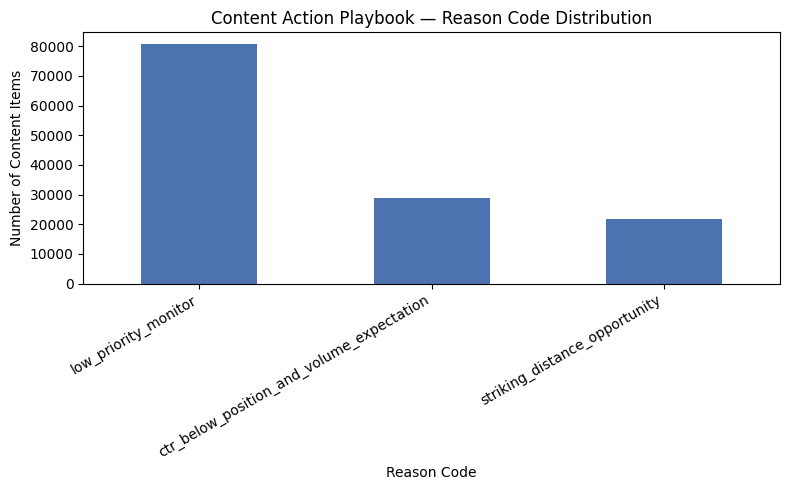

Saved figure to work/figures/reason_code_distribution.png


In [6]:
import matplotlib.pyplot as plt

reason_counts = queue["reason_code"].value_counts()

fig, ax = plt.subplots(figsize=(8, 5))
reason_counts.plot(kind="bar", ax=ax, color="#4C72B0")
ax.set_title("Content Action Playbook — Reason Code Distribution")
ax.set_xlabel("Reason Code")
ax.set_ylabel("Number of Content Items")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()

plt.savefig("work/figures/reason_code_distribution.png", dpi=150)
plt.show()

print("Saved figure to work/figures/reason_code_distribution.png")

In [5]:
import os, json
os.makedirs("work/outputs", exist_ok=True)
os.makedirs("work/figures", exist_ok=True)

queue.to_csv("work/outputs/action_playbook_queue.csv", index=False)

metrics = {
    "queue_rows": len(queue),
    "low_confidence_rows": int(len(low_confidence)),
    "top_reason_codes": queue["reason_code"].value_counts().to_dict()
}
with open("work/outputs/w07_metrics.json", "w") as f:
    json.dump(metrics, f, indent=2)

print("Exported queue CSV and metrics JSON.")

Exported queue CSV and metrics JSON.


## Self-check

Before you submit, confirm each line honestly:

- [x] Every section above is filled — markdown thinking AND the code that backs it
- [x] The notebook runs top to bottom with no errors (Runtime → Run all)
- [x] No client names, URLs, or private queries anywhere
- [x] My claims use careful words: observed, measured, directional, decision-support
- [x] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.